# Reading the Data

In [28]:
import os
import glob
import zipfile
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [15]:
# Define the zip file pattern
zip_pattern = "data/experiment_data_P0*.zip"

# Lists to store the parsed data
all_csv_trials = []
all_clicks = []
all_mouse_samples = []
all_demographics = []
raw_json_data = []

# Iterate through all zip files matching the pattern
for zip_path in glob.glob(zip_pattern):
    if os.path.exists(zip_path):
        print(f"Processing {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as z:
            # Identify the specific JSON and CSV files inside this zip
            file_names = z.namelist()
            json_filename = next((f for f in file_names if f.endswith('.json')), None)
            csv_filename = next((f for f in file_names if f.endswith('.csv')), None)

            # Read and process the CSV file (trial summary)
            if csv_filename:
                with z.open(csv_filename) as csv_file:
                    df_csv = pd.read_csv(csv_file)
                    all_csv_trials.append(df_csv)

            # Read and process the JSON file
            if json_filename:
                with z.open(json_filename) as json_file:
                    data = json.loads(json_file.read().decode('utf-8'))
                    raw_json_data.append(data)

                    p_code = data.get('participant_code', 'Unknown')

                    # Extract Demographics
                    demo = data.get('demographics', {})
                    # Add the participant code so we can merge it later
                    demo['participant_code'] = p_code
                    all_demographics.append(demo)

                    # Flatten click_events
                    if 'click_events' in data:
                        for click in data['click_events']:
                            click['participant_code'] = p_code
                            all_clicks.append(click)

                    # Flatten mouse_samples
                    if 'mouse_samples' in data:
                        for sample in data['mouse_samples']:
                            sample['participant_code'] = p_code
                            all_mouse_samples.append(sample)

print(f"Successfully processed {len(raw_json_data)} participant zip files.")

Processing data\experiment_data_P001.zip...
Processing data\experiment_data_P002.zip...
Processing data\experiment_data_P003.zip...
Processing data\experiment_data_P004.zip...
Processing data\experiment_data_P005.zip...
Processing data\experiment_data_P006.zip...
Processing data\experiment_data_P007.zip...
Processing data\experiment_data_P008.zip...
Processing data\experiment_data_P009.zip...
Processing data\experiment_data_P010.zip...
Processing data\experiment_data_P011.zip...
Processing data\experiment_data_P012.zip...
Processing data\experiment_data_P013.zip...
Processing data\experiment_data_P014.zip...
Processing data\experiment_data_P015.zip...
Processing data\experiment_data_P016.zip...
Processing data\experiment_data_P017.zip...
Processing data\experiment_data_P018.zip...
Processing data\experiment_data_P019.zip...
Processing data\experiment_data_P020.zip...
Successfully processed 20 participant zip files.


In [34]:
# Combine everything into master pandas DataFrames
if all_csv_trials:
    df_trials = pd.concat(all_csv_trials, ignore_index=True)
else:
    df_trials = pd.DataFrame()

df_clicks = pd.DataFrame(all_clicks)
df_mouse = pd.DataFrame(all_mouse_samples)
df_demographics = pd.DataFrame(all_demographics)

def convert_df_to_numeric(df):
    for col in df.columns:
        # Attempts to convert to number
        df[col] = pd.to_numeric(df[col], errors='ignore')
    return df

df_trials = convert_df_to_numeric(df_trials)
df_clicks = convert_df_to_numeric(df_clicks)
df_mouse = convert_df_to_numeric(df_mouse)
df_demographics = convert_df_to_numeric(df_demographics)

print(f"Created df_trials with {len(df_trials)} rows from the CSVs.")
print(f"Created df_clicks with {len(df_clicks)} rows from the JSONs.")
print(f"Created df_mouse with {len(df_mouse)} rows from the JSONs.")
print(f"Created df_demographics with {len(df_demographics)} rows from the JSONs.")

Created df_trials with 240 rows from the CSVs.
Created df_clicks with 1520 rows from the JSONs.
Created df_mouse with 301332 rows from the JSONs.
Created df_demographics with 20 rows from the JSONs.


In [35]:
df_trials.head()

,participant_number,participant_id,participant_code,session_id,assigned_condition,participant_yes_button_side,participant_no_button_side,response_side_assignment_method,presentation_order_method,counterbalance_index,...,total_mouse_distance_confidence1,total_mouse_distance_phase3,total_mouse_distance_confidence2,number_of_pauses_phase1,number_of_pauses_phase3,number_of_direction_changes_phase1,number_of_direction_changes_phase3,dwell_time_yes_button_ms,dwell_time_no_button_ms,dwell_time_confidence_scale_ms
0,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,left,right,fixed_by_participant_code,latin_square_counterbalancing,0,...,696,379,561,2,2,0,0,865,0,1449
1,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,left,right,fixed_by_participant_code,latin_square_counterbalancing,0,...,519,341,644,4,4,0,0,1486,547,1351
2,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,left,right,fixed_by_participant_code,latin_square_counterbalancing,0,...,581,433,927,2,2,0,0,2881,0,1900
3,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,left,right,fixed_by_participant_code,latin_square_counterbalancing,0,...,461,478,492,3,3,5,0,602,511,1326
4,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,left,right,fixed_by_participant_code,latin_square_counterbalancing,0,...,572,887,679,2,5,0,1,1359,483,2300


In [36]:
df_clicks.head()

,participant_number,participant_id,participant_code,session_id,assigned_condition,trial_index,problem_id,phase,clicked_element,click_timestamp_ms,x,y
0,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,trial_start,start_trial_button,125945,613,399
1,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,first_answer,yes_button,130033,229,575
2,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,confidence1,confidence_scale,132603,723,395
3,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,center_before_final,center_continue_button,136131,640,392
4,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,final_answer,yes_button,149957,341,546


In [37]:
df_mouse.head()

,participant_number,participant_id,participant_code,session_id,assigned_condition,trial_index,problem_id,phase,timestamp_ms_from_experiment_start,timestamp_ms_from_phase_start,x,y,viewport_width,viewport_height,element_or_zone,countdown_time_remaining_ms,mouse_button_down
0,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,first_answer,125972,26,613,399,1163,654,problem_text,9974.0,False
1,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,first_answer,125996,51,613,399,1163,654,problem_text,9950.0,False
2,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,first_answer,126023,77,613,399,1163,654,problem_text,9923.0,False
3,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,first_answer,126046,101,613,399,1163,654,problem_text,9899.0,False
4,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,first_answer,126071,126,613,399,1163,654,problem_text,9874.0,False


In [38]:
df_demographics.head()

,participant_code,age,gender,native_language,english_proficiency,logic_experience,dominant_hand,input_device,vision_status,motor_difficulty
0,P001,22,Woman,Portuguese,5,2,Right,Touchpad,Corrected with glasses/contact lenses,No
1,P002,23,Woman,arabic,4,5,Right,Touchpad,Normal,No
2,P003,26,Man,Hebrew,5,3,Right,Touchpad,Corrected with glasses/contact lenses,No
3,P004,21,Woman,Hebrew,5,4,Right,Touchpad,Normal,No
4,P005,23,Woman,Arabic,5,4,Left,Other,Corrected with glasses/contact lenses,No


In [56]:
# normalize languages
df_demographics['native_language'] = df_demographics['native_language'].str.lower().str.strip().str.title()

# Data Exploration

## Demographics

In [48]:
def plot_hist(df, column, title, xlabel, ylabel, bins=10, color='skyblue'):
    plt.figure(figsize=(8, 5))
    sns.histplot(df[column], bins=bins, kde=True, color=color)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

    print(f"{column}: M={df[column].mean():.2f}, SD={df[column].std():.2f}")

In [52]:
def plot_bar(df, column, title, xlabel, ylabel):
    plt.figure(figsize=(8, 5))
    value_counts = df[column].value_counts()
    sns.barplot(x=value_counts.index, y=value_counts.values, palette='pastel')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

    print(f"{column} value counts:\n{value_counts}")

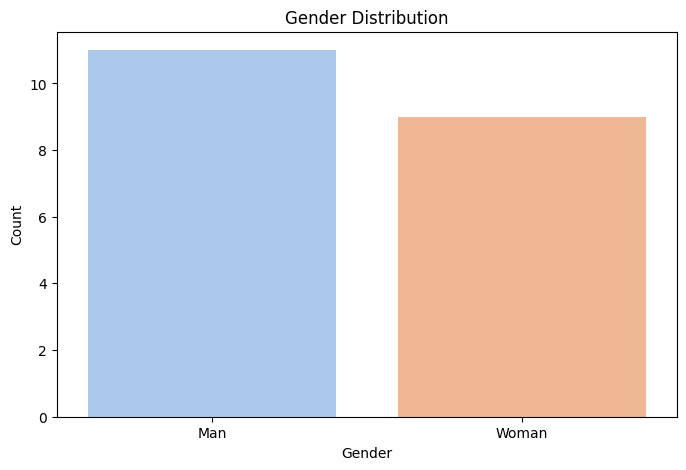

gender value counts:
gender
Man      11
Woman     9
Name: count, dtype: int64


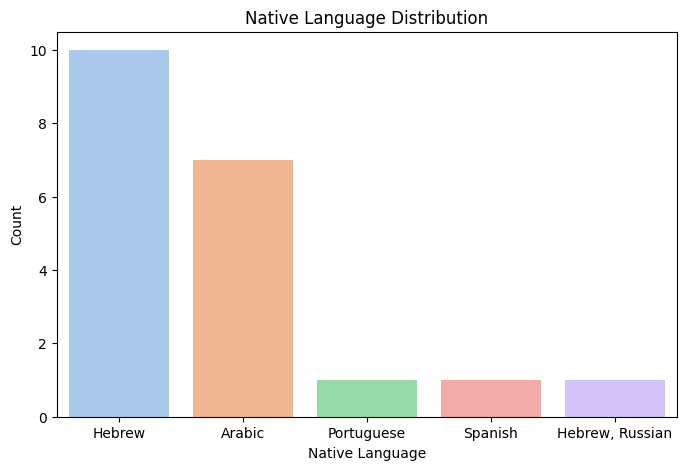

native_language value counts:
native_language
Hebrew             10
Arabic              7
Portuguese          1
Spanish             1
Hebrew, Russian     1
Name: count, dtype: int64


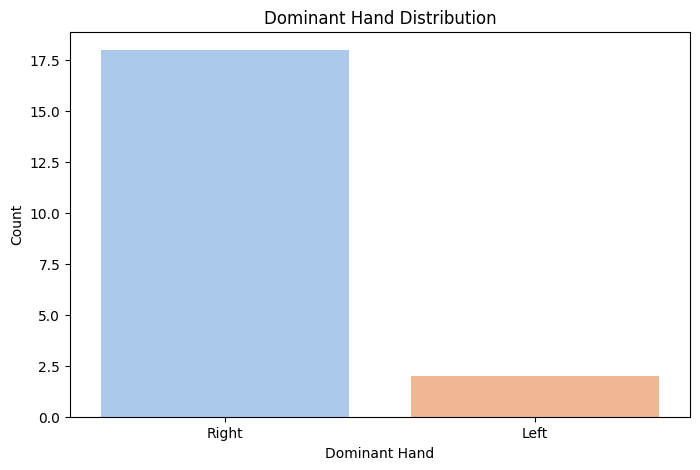

dominant_hand value counts:
dominant_hand
Right    18
Left      2
Name: count, dtype: int64


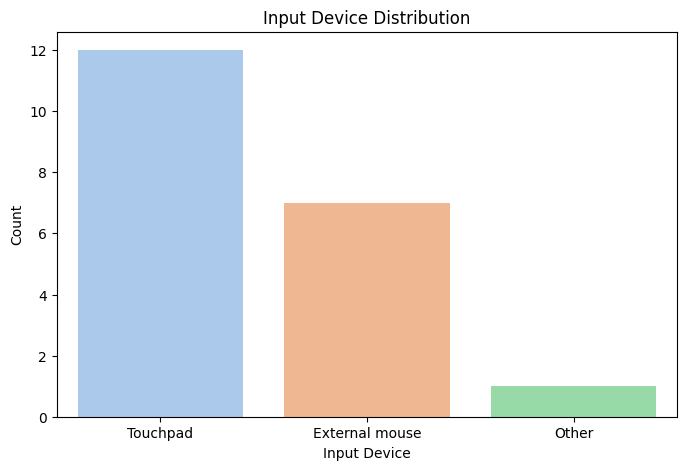

input_device value counts:
input_device
Touchpad          12
External mouse     7
Other              1
Name: count, dtype: int64


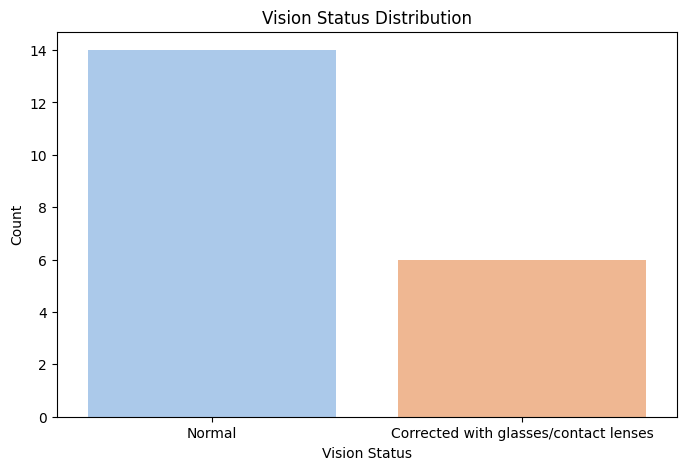

vision_status value counts:
vision_status
Normal                                   14
Corrected with glasses/contact lenses     6
Name: count, dtype: int64


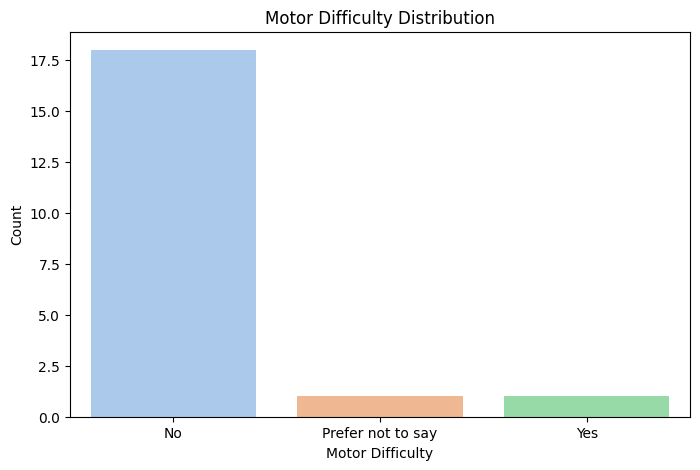

motor_difficulty value counts:
motor_difficulty
No                   18
Prefer not to say     1
Yes                   1
Name: count, dtype: int64


In [57]:
bar_cols = ['gender', 'native_language', 'dominant_hand', 'input_device', 'vision_status', 'motor_difficulty']
for col in bar_cols:
    plot_bar(df_demographics, col, f'{col.replace("_", " ").title()} Distribution', col.replace("_", " ").title(), 'Count')

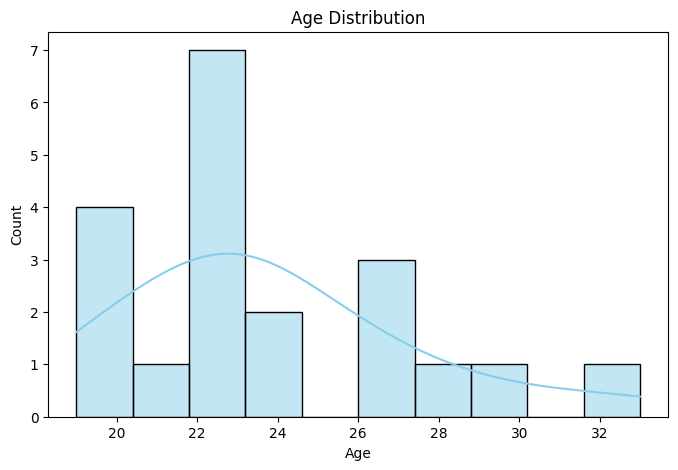

age: M=23.75, SD=3.61


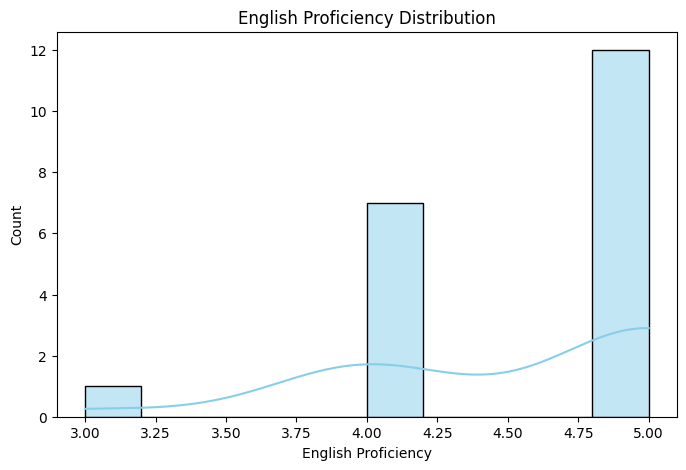

english_proficiency: M=4.55, SD=0.60


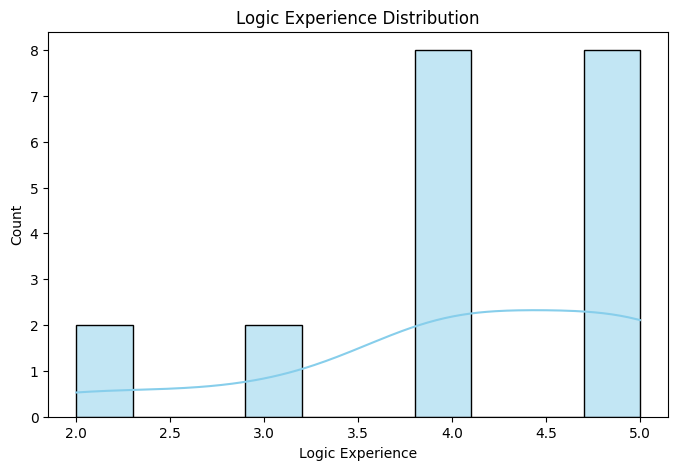

logic_experience: M=4.10, SD=0.97


In [51]:
hist_cols = ['age', 'english_proficiency', 'logic_experience']
for col in hist_cols:
    plot_hist(df_demographics, col, f'{col.replace("_", " ").title()} Distribution', col.replace("_", " ").title(), 'Count')